In [ ]:
from vllm import LLM, SamplingParams
import base64
import os
import pymupdf  # PyMuPDF
import mimetypes
import gc
import torch
from vllm.distributed.parallel_state import destroy_model_parallel, destroy_distributed_environment
import yaml
import json

# Global LLM instance
llm = None

def init_llm():
    global llm
    if llm is None:
        print("Initializing VLLM...")
        llm = LLM(
            # model="Qwen/Qwen3.5-4B",
            # model="Qwen/Qwen3.5-27B-FP8",
            model="Qwen/Qwen3.5-9B",
            tensor_parallel_size=1,
            max_model_len=262144,
            gpu_memory_utilization=0.8,
            trust_remote_code=True,
            # cpu_offload_gb=10
            # reasoning_parser="qwen3"
        )


In [3]:
# Init LLM early
try:
    init_llm()
except Exception as e:
    print(f"Failed to initialize VLLM: {e}")

Initializing VLLM...
INFO 03-05 15:59:48 [utils.py:238] non-default args: {'trust_remote_code': True, 'max_model_len': 262144, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'Qwen/Qwen3.5-9B'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 03-05 15:59:49 [model.py:530] Resolved architecture: Qwen3_5ForConditionalGeneration
INFO 03-05 15:59:49 [model.py:1553] Using max model len 262144
INFO 03-05 15:59:49 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 03-05 15:59:49 [config.py:232] Setting attention block size to 528 tokens to ensure that attention page size is >= mamba page size.
INFO 03-05 15:59:49 [config.py:263] Padding mamba page size by 0.76% to ensure that mamba page size and attention page size are exactly equal.
INFO 03-05 15:59:49 [vllm.py:747] Asynchronous scheduling is enabled.


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


WARNING 03-05 15:59:56 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore_DP0 pid=74684) INFO 03-05 15:59:57 [core.py:101] Initializing a V1 LLM engine (v0.16.1rc1.dev281+g612e7729c) with config: model='Qwen/Qwen3.5-9B', speculative_config=None, tokenizer='Qwen/Qwen3.5-9B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=262144, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=Struc

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:01,  2.88it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  2.72it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.69it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  3.03it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.92it/s]
(EngineCore_DP0 pid=74684) 


(EngineCore_DP0 pid=74684) INFO 03-05 16:00:06 [default_loader.py:293] Loading weights took 1.40 seconds
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:06 [gpu_model_runner.py:4344] Model loading took 17.66 GiB memory and 2.185292 seconds
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:07 [gpu_model_runner.py:5260] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:11 [decorators.py:465] Directly load AOT compilation from path /home/dw/.cache/vllm/torch_compile_cache/torch_aot_compile/3b6ec910592f23a00f1d5013addf285008f2e91dd6e368c4327a968e2925d15c/rank_0_0/model
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:11 [backends.py:913] Using cache directory: /home/dw/.cache/vllm/torch_compile_cache/159c6efef5/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:11 [backends.py:973] Dynamo bytecode transform time: 0.56 s
(EngineCore_DP0 pid=74684) INFO

(EngineCore_DP0 pid=74684) 2026-03-05 16:00:12,999 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore_DP0 pid=74684) 2026-03-05 16:00:13,057 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 39/39 [00:01<00:00, 33.68it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 31.12it/s]


(EngineCore_DP0 pid=74684) INFO 03-05 16:00:15 [gpu_model_runner.py:5366] Graph capturing finished in 3 secs, took -0.89 GiB
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:15 [core.py:282] init engine (profile, create kv cache, warmup model) took 8.79 seconds
(EngineCore_DP0 pid=74684) INFO 03-05 16:00:15 [vllm.py:747] Asynchronous scheduling is enabled.
INFO 03-05 16:00:15 [llm.py:388] Supported tasks: ['generate']


In [4]:
input_path = 'rational.pdf'

In [5]:
doc = pymupdf.open(input_path)
full_text_for_metadata = ''
first_page_image = None
for i, page in enumerate(doc):
    if i==0:
        zoom = 3.0
        mat = pymupdf.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat)
        img_bytes = pix.tobytes("png")
        # Encode bytes directly without saving to disk
        first_page_image = base64.b64encode(img_bytes).decode('utf-8')
        
    full_text_for_metadata += page.get_text() + "\n"
    # Optimization: Stop if we have enough text
    if len(full_text_for_metadata) > 2000:
        break

full_text_for_metadata

'Behavioral and Brain Sciences\ncambridge.org/bbs\nTarget Article\nCite this article: Lieder F, Griffiths TL. (2020)\nResource-rational analysis: Understanding\nhuman cognition as the optimal use of limited\ncomputational resources. Behavioral and Brain\nSciences 43, e1: 1–60. doi:10.1017/\nS0140525X1900061X\nTarget Article Accepted: 18 January 2019\nTarget Article Manuscript Online: 4 February\n2019\nCommentaries Accepted: 22 May 2019\nKeywords:\nbounded rationality; cognitive biases;\ncognitive mechanisms; cognitive modeling;\nrepresentations; resource rationality\nWhat is Open Peer Commentary? What\nfollows on these pages is known as a\nTreatment, in which a significant and\ncontroversial Target Article is published\nalong with Commentaries (p. 16) and an\nAuthor’s Response (p. 43). See bbsonline.\norg for more information.\n© Cambridge University Press 2019\nResource-rational analysis: Understanding\nhuman cognition as the optimal use of\nlimited computational resources\nFalk Liede

In [6]:
from vllm.sampling_params import StructuredOutputsParams
from pydantic import BaseModel
from typing import List, Optional
from pydantic import Field

In [17]:


class Metadata(BaseModel):
    title: str = Field(description="Title of the paper")
    author: Optional[List[str]] = Field(None, description="List of authors")
    date: Optional[str] = Field(None, description="Publication date in YYYY-MM-DD format if available, otherwise YYYY")
    keywords: Optional[List[str]] = Field(None, description="List of keywords")
    journal: Optional[str] = Field(None, description="Journal or Conference name")

In [20]:
try:
    # Pydantic v2
    json_schema = Metadata.model_json_schema()
except AttributeError:
    # Pydantic v1
    json_schema = Metadata.schema()

structured_outputs_params = StructuredOutputsParams(json=json_schema)
structured_outputs_params

StructuredOutputsParams(json={'properties': {'title': {'description': 'Title of the paper', 'title': 'Title', 'type': 'string'}, 'author': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': None, 'description': 'List of authors', 'title': 'Author'}, 'date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'description': 'Publication date in YYYY-MM-DD format if available, otherwise YYYY', 'title': 'Date'}, 'keywords': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': None, 'description': 'List of keywords', 'title': 'Keywords'}, 'journal': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'description': 'Journal or Conference name', 'title': 'Journal'}}, 'required': ['title'], 'title': 'Metadata', 'type': 'object'}, regex=None, choice=None, grammar=None, json_object=None, disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, whitespace_pat

In [ ]:

def extract_metadata(text, image=None):
    """
    Extracts the Title and Author from the text using the LLM and formats it as YAML frontmatter.
    """
    print("Extracting metadata (Title/Author)...")
    sampling_params = SamplingParams(
        temperature=0.7,
        max_tokens=20000,
        structured_outputs=structured_outputs_params
    )

    # Take the first 3000 characters which should contain the title/abstract
    context_text = text[:3000]
    # context_text = text[5000:]
    
    messages = [
        # {"role": "system", "content": system_prompt},
        {
            "role": "user", 
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{image}"
                    }
                },
                {
                    "type": "text",
                    "text":context_text
                }
            
            ]
        },
        ]
    try:
        outputs = llm.chat(
            messages=messages, 
            sampling_params=sampling_params,
            chat_template_kwargs={"enable_thinking": False}

        )
        generated_text = outputs[0].outputs[0].text.strip()
        
        # Clean up if the model wrapped it in code blocks despite instructions
        if generated_text.startswith("```"):
            lines = generated_text.split('\n')
            # Remove first and last lines if they are code fences
            if lines[0].startswith("```"): lines = lines[1:]
            if lines and lines[-1].startswith("```"): lines = lines[:-1]
            generated_text = "\n".join(lines).strip()
            
        return json.loads(generated_text)
    except Exception as e:
        print(f"Error extracting metadata: {e}")
        return {}

Extracting metadata (Title/Author)...
[{'role': 'user', 'content': [{'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'text', 'text': 'Behavioral and Brain Sciences\ncambridge.org/bbs\nTarget Article\nCite this article: Lieder F, Griffiths TL. (2020)\nResource-rational analysis: Understanding\nhuman cognition as the optimal use of limited\ncomputational resources. Behavioral and Brain\nSciences 43, e1: 1–60. doi:10.1017/\nS0140525X1900061X\nTarget Article Accepted: 18 January 2019\nTarget Article Manuscript Online: 4 February\n2019\nCommentaries Accepted: 22 May 2019\nKeywords:\nbounded rationality; cognitive biases;\ncognitive mechanisms; cognitive modeling;\nrepresentations; resource rationality\nWhat is Open Peer Commentary? What\nfollows on these pages is known as a\nTreatment, in which a significant and\ncontroversial Target Article is published\nalong with Commentaries (p. 16) and an\nAuthor’s Response (p. 43). See bbsonline.\norg for more information.\n© Cambridge Univer
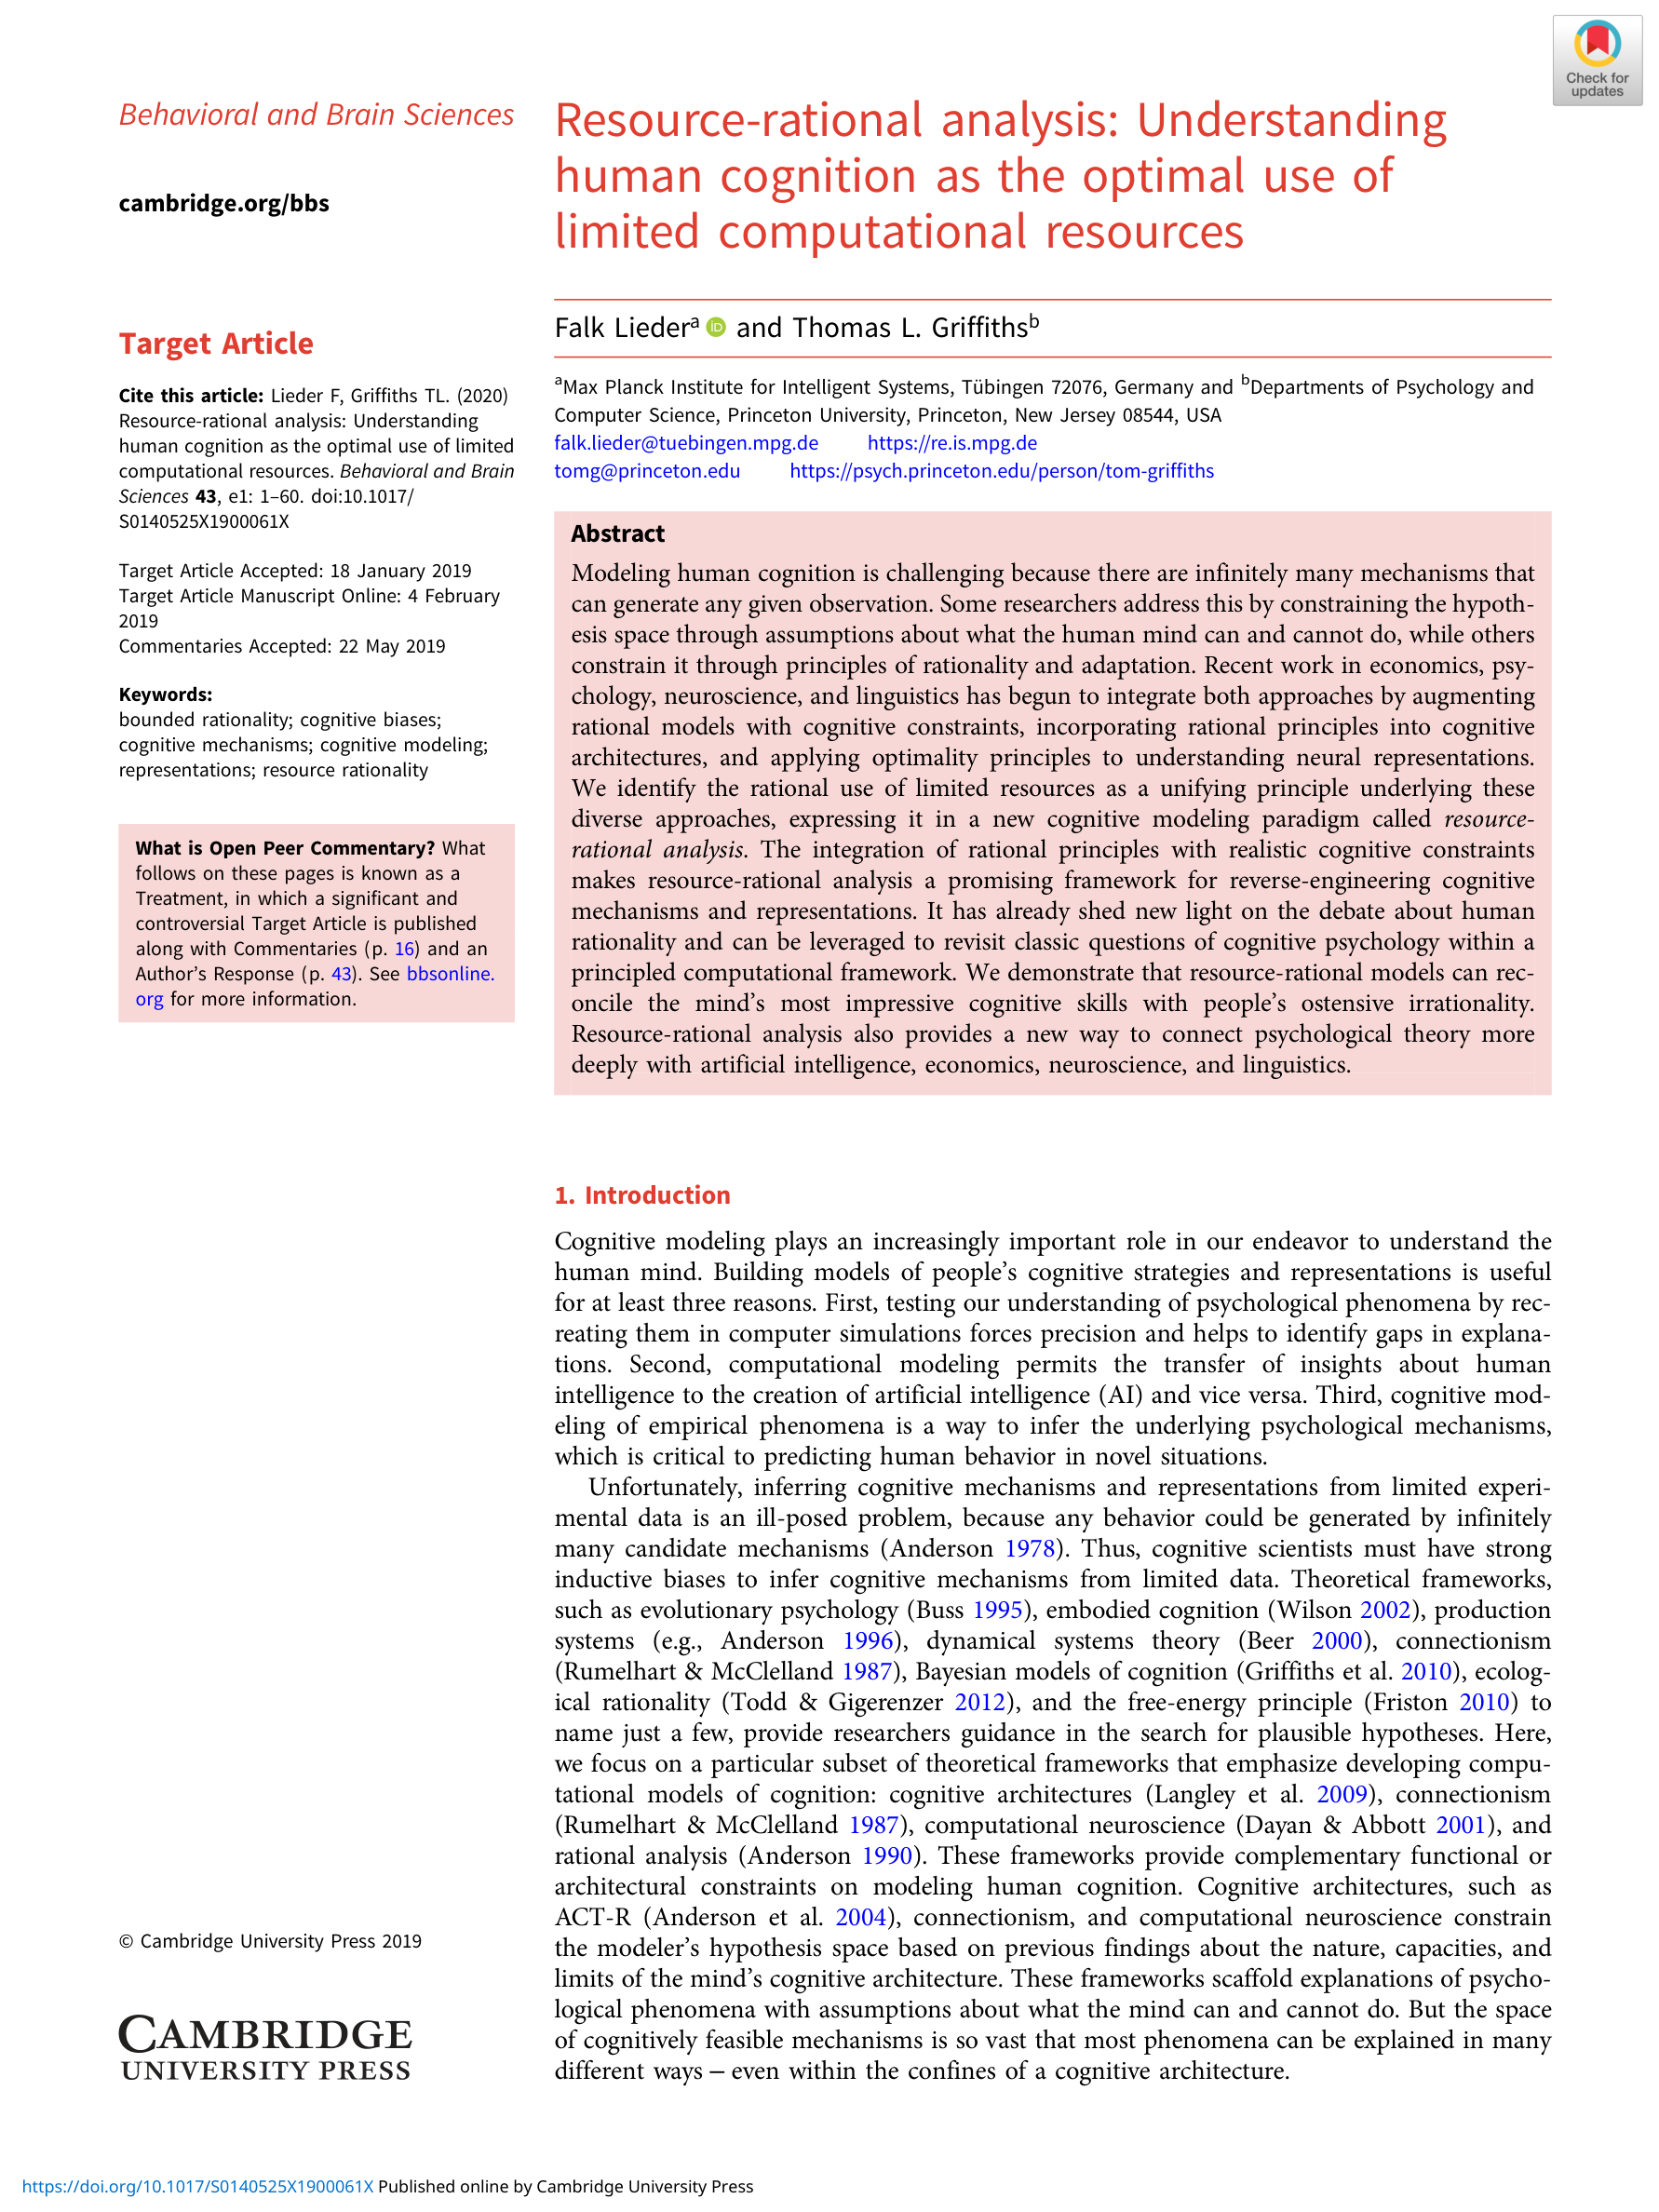

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

{"title": "Resource-rational analysis: Understanding human cognition as the optimal use of limited computational resources", "author": [ "Falk Lieder", "Thomas L. Griffiths" ], "journal": "Behavioral and Brain Sciences" }


{'title': 'Resource-rational analysis: Understanding human cognition as the optimal use of limited computational resources',
 'author': ['Falk Lieder', 'Thomas L. Griffiths'],
 'journal': 'Behavioral and Brain Sciences'}

In [22]:
yaml_info = extract_metadata(full_text_for_metadata, image = first_page_image)
# print(yaml_info)
(yaml_info)

In [ ]:

# Create a copy of yaml_info to avoid modifying the original
data = yaml_info.copy()

# Remove keys with None values to keep the frontmatter clean
# This ensures fields like 'keywords' don't appear if they are null
clean_data = {k: v for k, v in data.items() if v is not None}

# Dump to YAML string
# allow_unicode=True ensures characters like accents are preserved
# default_flow_style=False ensures block style (lists are one item per line)
# sort_keys=False preserves the order of keys (title, author, date...)
yaml_str = yaml.dump(clean_data, allow_unicode=True, default_flow_style=False, sort_keys=False)

# Create frontmatter string
frontmatter = f"---\n{yaml_str}---\n"

print(frontmatter)

---
title: 'Resource-rational analysis: Understanding human cognition as the optimal use
  of limited computational resources'
author:
- Falk Lieder
- Thomas L. Griffiths
journal: Behavioral and Brain Sciences
---

